# Supplementary Figure S28: `s28_superstim_scatter_venus`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_superstim_scatter_venus.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

This figure shows the most extreme super-stimuli for the V3/V4 sites of Monkey V, both as images and as points in the predicted-versus-measured plane. Super-stimuli are accentuated images whose measured response fell outside the site's natural calibration range, with at least three trial repeats so the estimate is not a single noisy trial. The left half is a ten-by-ten mosaic of the strongest cases, split into super-drive at the top and super-suppress at the bottom; the right half plots the same stimuli against the gray calibration cloud. Everything is read from a preprocessed cache; the script only lays it out.

## What the script says about itself

Supp Fig (superstim_scatter_venus) - super-stimuli in the predicted-vs-measured plane, Monkey V.

The `figS27e_superstimuli_venus_suppress` (Monkey V, drive+suppress) variant. DiCarlo/Kar style, z units. Left: 10x10 gallery of the most intense super-stimuli (measured with >=3 trial repeats), image borders colored by generating model, split into 70 super-drive (top) and 30 super-suppress (bottom). Right: predicted vs measured z scatter - grey calibration (encoding) cloud (dots + SEM whiskers) hugging unity, the super-stimuli as bigger model-colored dots (+ SEM whiskers) beyond it, and the outermost called out to their images placed in the scatter's whitespace with dashed leader lines.

Layout/aspect and every marker/color/annotation are preserved from the original; only the data source (pnc.preproc.loader, venus sites) and output stem (manifest slug `superstim_scatter_venus`) differ. Authored at final print width (WIDTH_2COL_MM).

Reads <preprocessed_data>/sup_superstim_scatter_venus.pkl, built by scripts/preprocessing/build_superstim_scatter_caches.py.

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`CACHE` points at the per-stimulus table and calibration cloud built by the preprocessing script named in `BUILD_HINT`. `MIN_REPS` is the repeat threshold, and `N_DRIVE_DS` and `N_SUPP_DS` set how many drive and suppress stimuli fill the mosaic (they sum to the hundred cells). `MOSAIC_BOX` and `SCAT_RECT` fix the two halves in figure fractions, and `UL_SLOTS` and `LR_SLOTS` are the pre-chosen positions for the thumbnail callouts in the scatter's empty corners.

In [2]:
import os

import pickle

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.utils import (apply_figure_style, FONT_FAMILY, DPI, FIG_FACECOLOR, MM, WIDTH_2COL_MM,
                       MODEL_ORDER, MODEL_SHORT_NAMES, get_model_color, save_fig,
                       MONKEY_COLORS, STIMULI_CONTROL_PATH)

import numpy as np

import pandas as pd

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from matplotlib.patches import ConnectionPatch

from PIL import Image

apply_figure_style()

_M = _fig('superstim_scatter_venus'); STEM = output_name('superstim_scatter_venus')



CACHE = os.path.join(str(paths.preprocessed_data()), 'sup_superstim_scatter_venus.pkl')

BUILD_HINT = 'python scripts/preprocessing/build_superstim_scatter_caches.py'

# AlexNet is the effectively-untrained control -> display "Untrained" (convention).
MODEL_SHORT_NAMES = dict(MODEL_SHORT_NAMES)

MODEL_SHORT_NAMES['AlexNet_training_seed_01'] = 'Untrained'

MIN_REPS = 3

N_DRIVE_DS, N_SUPP_DS = 70, 30

# --- print-size layout (take7 aspect 16.5:8.4 preserved) ----------------------
FIGW = WIDTH_2COL_MM * MM

FIGH = FIGW * (8.4 / 16.5)

MOSAIC_BOX = (0.035, 0.055, 0.45, 0.885)

SCAT_RECT = (0.555, 0.135, 0.40, 0.80)

FS_AX, FS_TICK, FS_LET = 7, 6, 10        # print sizes; letter ~= 1.5x title (take4 ratio)

UL_SLOTS = [(0.01, 0.85), (0.01, 0.715), (0.01, 0.58),
            (0.135, 0.87), (0.135, 0.735), (0.135, 0.60)]

LR_SLOTS = [(0.50, 0.02), (0.62, 0.02), (0.74, 0.02), (0.86, 0.02),
            (0.50, 0.155), (0.62, 0.155), (0.74, 0.155), (0.86, 0.155)]

THUMB_H = 0.115

THUMB_W = THUMB_H * (SCAT_RECT[3] * FIGH) / (SCAT_RECT[2] * FIGW)

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

The helpers work from the outside in: `_relocate` fixes file paths, `_load_img` shows one image, `draw_mosaic` fills the left half, `draw_scatter` and `add_callout` fill the right half, and `render` selects the stimuli and calls the rest.

### `_relocate(path)`

The cache stores each image path as built (<STIMULI_CONTROL_PATH>/<folder>/<file>); re-root it under the current STIMULI_CONTROL_PATH.

The cache stores absolute paths from the machine that built it. This re-roots each path under the current stimulus directory, keeping only the folder and file names.

In [3]:
def _relocate(path):
    """The cache stores each image path as built (<STIMULI_CONTROL_PATH>/<folder>/<file>);
    re-root it under the current STIMULI_CONTROL_PATH."""
    return os.path.join(STIMULI_CONTROL_PATH, os.path.basename(os.path.dirname(path)),
                        os.path.basename(path))

### `_load_img(ax, path)`

------------------------- verbatim take7 rendering ---------------------------

Displays an image in an axes with ticks removed, or fills the axes light gray if the file is missing, so a missing image is visible but does not stop the render.

In [4]:
# ------------------------- verbatim take7 rendering ---------------------------

def _load_img(ax, path):
    if path is not None and os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    else:
        ax.set_facecolor('#f0f0f0')
    ax.set_xticks([]); ax.set_yticks([])

### `draw_mosaic(fig, items, split_after=None)`

Places a hundred small axes in a ten-by-ten grid inside `MOSAIC_BOX`. When `split_after` is given, it leaves a gap after that many rows, draws a separator line, and labels the upper block super-drive and the lower block super-suppress. Each tile's border takes the color of the model that generated the image.

In [5]:
def draw_mosaic(fig, items, split_after=None):
    mx, my, mw, mh = MOSAIC_BOX
    pad = 0.0035
    cw = mw / 10
    gap = 0.02 if split_after else 0.0
    ch = (mh - gap) / 10
    n_bot = (10 - split_after) if split_after else 0

    def ypos(r):
        if not split_after:
            return my + (9 - r) * ch + pad
        if r < split_after:
            return my + n_bot * ch + gap + (split_after - 1 - r) * ch + pad
        return my + (n_bot - 1 - (r - split_after)) * ch + pad

    for k in range(100):
        r, c = k // 10, k % 10
        ax = fig.add_axes([mx + c * cw + pad, ypos(r), cw - 2 * pad, ch - 2 * pad])
        ax.set_xticks([]); ax.set_yticks([])
        row = items[k] if k < len(items) else None
        if row is not None:
            _load_img(ax, row['path'])
            col = get_model_color(row['model'])
            for sp in ax.spines.values():
                sp.set_color(col); sp.set_linewidth(1.1)
        else:
            ax.axis('off')

    if split_after:
        yline = my + n_bot * ch + gap / 2
        fig.add_artist(Line2D([mx, mx + mw], [yline, yline], transform=fig.transFigure,
                              color='#555', lw=1.2, zorder=10))
        fig.text(0.022, my + n_bot * ch + gap + split_after * ch / 2, 'super-drive',
                 rotation=90, ha='center', va='center', fontsize=FS_TICK, color='#555',
                 fontstyle='italic', fontfamily=FONT_FAMILY)
        fig.text(0.022, my + n_bot * ch / 2, 'super-suppress', rotation=90, ha='center',
                 va='center', fontsize=FS_TICK, color='#555', fontstyle='italic',
                 fontfamily=FONT_FAMILY)

### `add_callout(ax, row, slot)`

Adds one thumbnail as an inset at a given slot, borders it in the model color, and draws a dashed leader from the stimulus's point in the scatter to the thumbnail center.

In [6]:
def add_callout(ax, row, slot):
    tax = ax.inset_axes([slot[0], slot[1], THUMB_W, THUMB_H])
    _load_img(tax, row['path'])
    col = get_model_color(row['model'])
    for sp in tax.spines.values():
        sp.set_color(col); sp.set_linewidth(1.2)
    con = ConnectionPatch(xyA=(row['pred'], row['meas']), coordsA=ax.transData,
                          xyB=(0.5, 0.5), coordsB=tax.transAxes, linestyle='--',
                          linewidth=0.7, color=col, alpha=0.8, zorder=2)
    ax.add_artist(con)

### `draw_scatter(ax, cloud, dots, drive, supp, suppress)`

Plots the gray calibration cloud with SEM whiskers and a dotted identity line, then the super-stimuli as larger model-colored dots with their own whiskers. When `suppress` is true the y-range is extended downward so the suppress points have room. It then calls out the highest-measured drive stimuli to the upper-left slots and the lowest-measured suppress stimuli to the lower-right slots, and returns the list of models present for the legend.

In [7]:
def draw_scatter(ax, cloud, dots, drive, supp, suppress):
    xmin = min(cloud['pred'].min(), dots['pred'].min())
    xmax = max(cloud['pred'].max(), dots['pred'].max())
    ymin = min(cloud['meas'].min(), dots['meas'].min())
    ymax = max(cloud['meas'].max(), dots['meas'].max())
    xr, yr = xmax - xmin, ymax - ymin
    xlo, xhi = xmin - 0.06 * xr, xmax + 0.06 * xr
    ylo = ymin - 0.06 * yr - (0.20 * yr if suppress else 0)   # shift cloud up
    yhi = ymax + 0.06 * yr
    d0, d1 = max(xlo, ylo), min(xhi, yhi)

    ax.errorbar(cloud['pred'], cloud['meas'], yerr=cloud['sem'], fmt='none',
                ecolor='#C2C2C2', elinewidth=0.3, alpha=0.35, zorder=1)
    ax.scatter(cloud['pred'], cloud['meas'], s=8, color='#A6A6A6', alpha=0.42,
               edgecolors='none', zorder=2)
    ax.plot([d0, d1], [d0, d1], ls=':', color='black', lw=0.9, alpha=0.6, zorder=3)
    ax.errorbar(dots['pred'], dots['meas'], yerr=dots['sem'], fmt='none', ecolor='#4D4D4D',
                elinewidth=0.6, alpha=0.6, zorder=4)
    present = [m for m in MODEL_ORDER if (dots['model'] == m).any()]
    for m in present:
        s = dots[dots['model'] == m]
        ax.scatter(s['pred'], s['meas'], s=20, color=get_model_color(m),
                   edgecolors='white', linewidths=0.4, alpha=0.95, zorder=5)
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    ax.set_xlabel('Predicted response (z)', fontsize=FS_AX)
    ax.set_ylabel('Measured neural (z)', fontsize=FS_AX)
    ax.tick_params(labelsize=FS_TICK)
    ax.text(0.13, 0.55 if suppress else 0.44, 'calibration set', transform=ax.transAxes,
            ha='center', va='center', fontsize=FS_TICK, color='#8A8A8A',
            fontstyle='italic', fontfamily=FONT_FAMILY)

    ul = drive.nlargest(len(UL_SLOTS), 'meas')
    if suppress:
        lr = supp.nsmallest(len(LR_SLOTS), 'meas')
    else:
        lr = drive.drop(ul.index).nlargest(len(LR_SLOTS), 'pred')
    for (_, row), slot in zip(ul.iterrows(), UL_SLOTS):
        add_callout(ax, row, slot)
    for (_, row), slot in zip(lr.iterrows(), LR_SLOTS):
        add_callout(ax, row, slot)
    return present

### `render(out_dir, cloud, acc, suppress=True)`

Filters the table to stimuli with enough repeats, takes the top drive cases by measured response and the bottom suppress cases, builds the mosaic item list in that order, draws both halves, adds the monkey label and a model legend, and saves.

In [8]:
def render(out_dir, cloud, acc, suppress=True):
    a = acc[acc['n_reps'] >= MIN_REPS]
    drive_all = a[a['is_super']].sort_values('meas', ascending=False).reset_index(drop=True)
    if suppress:
        drive = drive_all.head(N_DRIVE_DS)
        supp = (a[a['is_supersuppress']].sort_values('meas')
                .head(N_SUPP_DS).reset_index(drop=True))
        dots = pd.concat([drive, supp], ignore_index=True)
        items = ([drive.iloc[k] if k < len(drive) else None for k in range(N_DRIVE_DS)] +
                 [supp.iloc[k] if k < len(supp) else None for k in range(N_SUPP_DS)])
    else:
        drive = drive_all.head(100)
        supp = drive.iloc[0:0]
        dots = drive
        items = [drive.iloc[k] if k < len(drive) else None for k in range(100)]

    fig = plt.figure(figsize=(FIGW, FIGH), facecolor=FIG_FACECOLOR)
    draw_mosaic(fig, items, split_after=(N_DRIVE_DS // 10) if suppress else None)
    ax = fig.add_axes(SCAT_RECT)
    present = draw_scatter(ax, cloud, dots, drive, supp, suppress)

    fig.text(0.035, 0.975, 'V3/V4 (Monkey V)', fontsize=6.5, fontweight='bold', ha='left',
             va='center', fontfamily=FONT_FAMILY, color=MONKEY_COLORS['venus'])
    handles = [Line2D([0], [0], marker='o', ls='', mfc=get_model_color(m), mec='white',
                      mew=0.4, ms=5, label=MODEL_SHORT_NAMES[m]) for m in present]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.755, -0.02),
               ncol=5, frameon=False, fontsize=FS_TICK - 1, columnspacing=1.1,
               handletextpad=0.3)

    path = save_fig(fig, os.path.join(out_dir, STEM))
    plt.close(fig)
    print(f'Saved -> {path}  (drive={len(drive)}, suppress={len(supp)})')
    return path

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

`main` is a single step: load the cache, fix the image paths, and hand the calibration cloud and stimulus table to `render` with the drive-plus-suppress layout enabled.

In [9]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the pickle, re-roots every image path with `_relocate`, and renders the figure; `png` receives the saved path.

In [10]:
d = pickle.load(open(paths.require(CACHE, hint=BUILD_HINT), 'rb'))
acc = d['acc'].copy(); acc['path'] = acc['path'].map(_relocate)
png = render(out_dir, d['cloud'], acc, suppress=True)

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s28_superstim_scatter_venus.png  (drive=70, suppress=30)


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s28_superstim_scatter_venus.png` in the output directory).

Notice that the calibration cloud hugs the identity line while the super-stimuli sit well outside it, above for drive and below for suppress. The mosaic borders and the dot colors share the model palette, so you can read off which models produced the extremes.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s28_superstim_scatter_venus.png


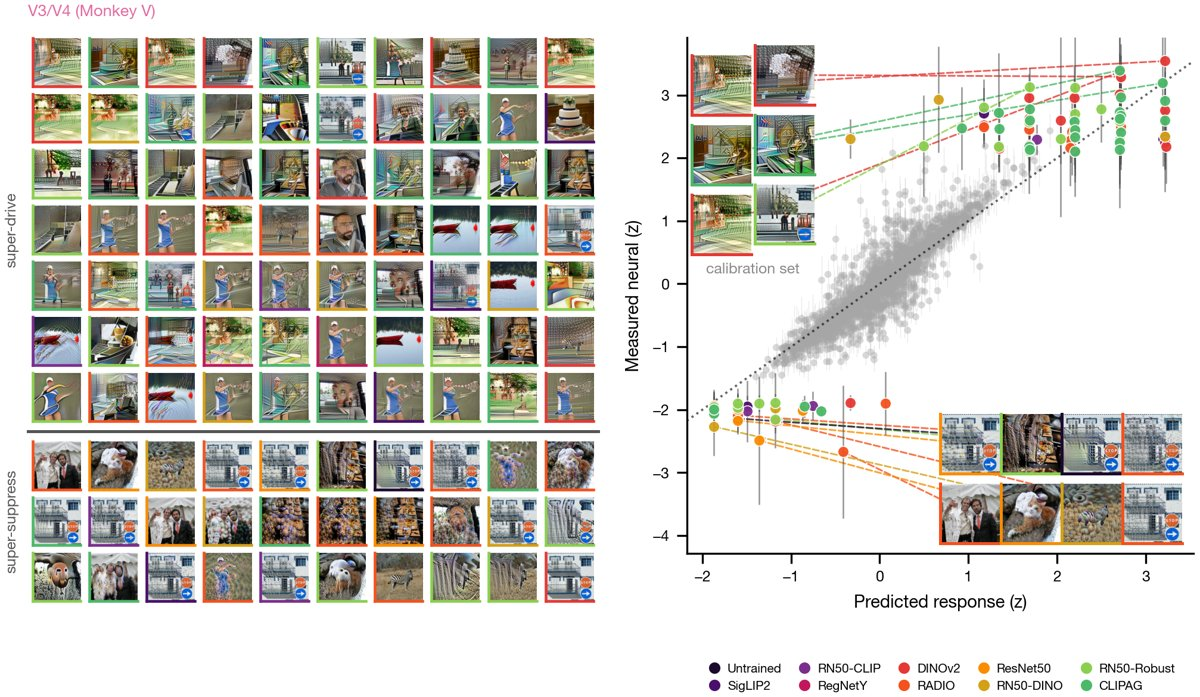

In [11]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S28. Super-stimulus response scatter, Monkey V.** Super-stimuli were accentuated images whose measured control response (with $\geq 3$ trial repeats) fell outside the site's natural-image calibration range: $z > \mathrm{q99}$ for super-drive and $z < \mathrm{q01}$ for super-suppress. (Left) A $10 \times 10$ gallery of the strongest super-stimuli, split into $70$ super-drive (top) and $30$ super-suppress (bottom). (Right) Predicted versus measured responses ($z$ units) for the same stimuli, shown as model-colored points with SEM whiskers. The gray calibration-set points with SEM whiskers follow the dotted identity line; the outermost super-stimuli are called out to their images with dashed leader lines. Image borders and points are colored by the generating model.